# Day 25 - Model Validation with Cross-Validation
60 Days Data Science | Phase: Model Validation

**Date:** 07 June 2026  
**Name:** Rajesh Yadav


## Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("Imports completed successfully!")


Imports completed successfully!


## Step 2 - Load Data

In [2]:
# Using the Telco Customer Churn dataset
dataset_path = '../day15/telco_customer_churn.csv'
if not os.path.exists(dataset_path):
    dataset_path = 'telco_customer_churn.csv'

df = pd.read_csv(dataset_path)
print(f"Data loaded. Shape: {df.shape}")

# Basic preprocessing
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

# Encode categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Separate features and target
X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

# Standardize features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features shape: {X_scaled.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")


Data loaded. Shape: (7043, 21)
Features shape: (7043, 30)
Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Step 3 - Train-Test Split Variance

In [3]:
# We will run 10 different train-test splits with different random seeds
# to see how much the test scores fluctuate.

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

split_results = []

for seed in range(1, 11):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        auc = roc_auc_score(y_test, probs)
        
        split_results.append({
            'Seed': seed,
            'Model': name,
            'Accuracy': acc,
            'F1': f1,
            'ROC-AUC': auc
        })

df_splits = pd.DataFrame(split_results)
print("Finished running 10 different train-test splits.")
print("\nSummary of ROC-AUC across splits:")
print(df_splits.groupby('Model')['ROC-AUC'].agg(['mean', 'std', 'min', 'max']).round(4))


Finished running 10 different train-test splits.

Summary of ROC-AUC across splits:
                       mean     std     min     max
Model                                              
Decision Tree        0.8250  0.0096  0.8110  0.8462
Logistic Regression  0.8427  0.0099  0.8271  0.8574
Random Forest        0.8418  0.0120  0.8238  0.8596


## Step 4 - K-Fold Cross Validation

In [4]:
# Now we run 5-fold and 10-fold Stratified Cross-Validation on the entire dataset
cv_results = []

for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    for name, model in models.items():
        # Evaluate ROC-AUC
        auc_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='roc_auc')
        # Evaluate Accuracy
        acc_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='accuracy')
        # Evaluate F1
        f1_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1')
        
        cv_results.append({
            'Model': name,
            'CV-Folds': k,
            'ROC-AUC Mean': auc_scores.mean(),
            'ROC-AUC Std': auc_scores.std(),
            'Accuracy Mean': acc_scores.mean(),
            'Accuracy Std': acc_scores.std(),
            'F1 Mean': f1_scores.mean(),
            'F1 Std': f1_scores.std()
        })

df_cv = pd.DataFrame(cv_results)
print("Finished K-Fold Cross Validation.")
print("\nCV Performance Summary:")
print(df_cv.round(4).to_string(index=False))


Finished K-Fold Cross Validation.

CV Performance Summary:
              Model  CV-Folds  ROC-AUC Mean  ROC-AUC Std  Accuracy Mean  Accuracy Std  F1 Mean  F1 Std
Logistic Regression         5        0.8451       0.0133         0.8049        0.0110   0.5997  0.0281
      Decision Tree         5        0.8257       0.0125         0.7909        0.0104   0.5671  0.0295
      Random Forest         5        0.8440       0.0119         0.7954        0.0113   0.5365  0.0292
Logistic Regression        10        0.8454       0.0176         0.8036        0.0160   0.5952  0.0371
      Decision Tree        10        0.8275       0.0162         0.7877        0.0142   0.5434  0.0314
      Random Forest        10        0.8446       0.0189         0.7972        0.0172   0.5450  0.0350


## Step 5 - Compare Train-Test vs Cross Validation

Saved cv_results.csv


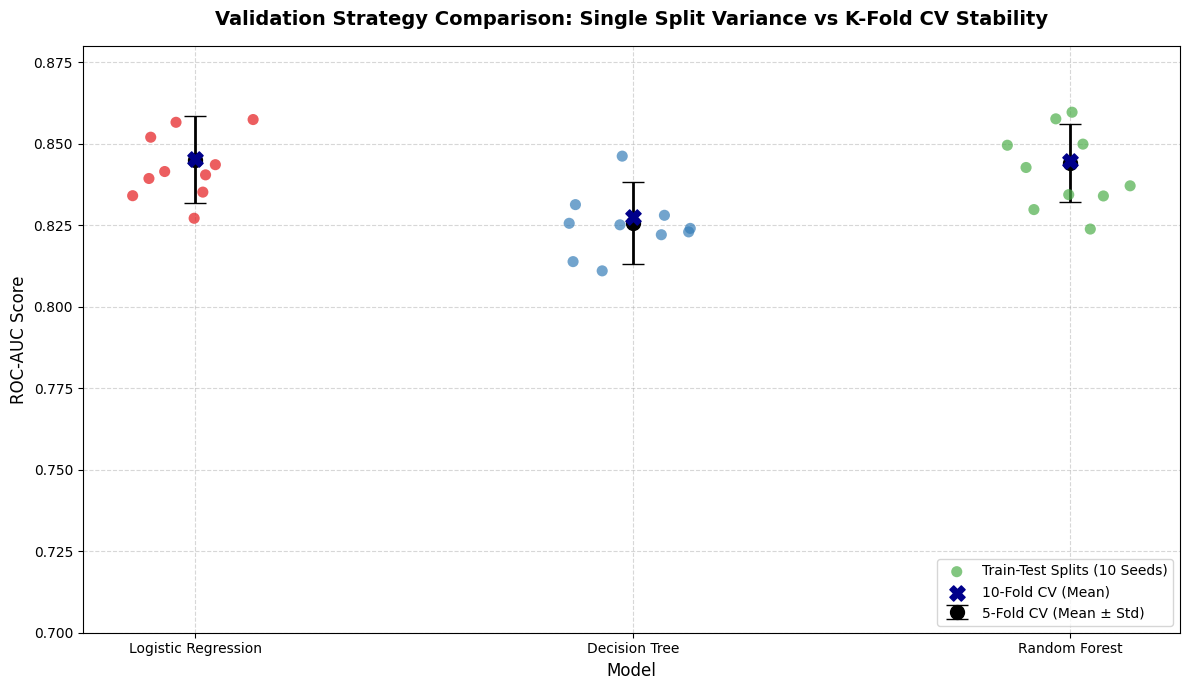

Saved cv_comparison.png


In [5]:
# Let's save the results to a CSV file
df_cv.to_csv('cv_results.csv', index=False)
print("Saved cv_results.csv")

# Create a visualization showing the comparison
plt.figure(figsize=(12, 7))

# Plot train-test split scores as individual dots to show their spread
sns.stripplot(
    data=df_splits,
    x='Model',
    y='ROC-AUC',
    jitter=0.15,
    size=8,
    alpha=0.7,
    palette='Set1',
    label='Train-Test Splits (10 Seeds)'
)

# Plot 5-fold and 10-fold CV mean scores as horizontal markers or bars
models_list = list(models.keys())
x_coords = np.arange(len(models_list))

# Filter 5-fold CV means
cv5_means = df_cv[df_cv['CV-Folds'] == 5].set_index('Model').loc[models_list, 'ROC-AUC Mean'].values
cv5_stds = df_cv[df_cv['CV-Folds'] == 5].set_index('Model').loc[models_list, 'ROC-AUC Std'].values

# Filter 10-fold CV means
cv10_means = df_cv[df_cv['CV-Folds'] == 10].set_index('Model').loc[models_list, 'ROC-AUC Mean'].values

# Overlay the 5-fold CV Mean
plt.errorbar(
    x_coords,
    cv5_means,
    yerr=cv5_stds,
    fmt='o',
    color='black',
    markersize=10,
    capsize=8,
    elinewidth=2,
    label='5-Fold CV (Mean ± Std)'
)

# Overlay the 10-fold CV Mean
plt.scatter(
    x_coords,
    cv10_means,
    color='darkblue',
    marker='X',
    s=120,
    zorder=5,
    label='10-Fold CV (Mean)'
)

plt.title('Validation Strategy Comparison: Single Split Variance vs K-Fold CV Stability', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.70, 0.88)
plt.grid(True, linestyle='--', alpha=0.5)

# Deduplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cv_comparison.png")


## Step 6 - Model Stability Analysis

In [6]:
# Analyze standard deviations of model performance
for idx, row in df_cv.iterrows():
    print(f"Model: {row['Model']} | CV Folds: {row['CV-Folds']}")
    print(f"  ROC-AUC: {row['ROC-AUC Mean']:.4f} ± {row['ROC-AUC Std']:.4f}")
    print(f"  Accuracy: {row['Accuracy Mean']:.4f} ± {row['Accuracy Std']:.4f}")
    print(f"  F1-Score: {row['F1 Mean']:.4f} ± {row['F1 Std']:.4f}\n")


Model: Logistic Regression | CV Folds: 5
  ROC-AUC: 0.8451 ± 0.0133
  Accuracy: 0.8049 ± 0.0110
  F1-Score: 0.5997 ± 0.0281

Model: Decision Tree | CV Folds: 5
  ROC-AUC: 0.8257 ± 0.0125
  Accuracy: 0.7909 ± 0.0104
  F1-Score: 0.5671 ± 0.0295

Model: Random Forest | CV Folds: 5
  ROC-AUC: 0.8440 ± 0.0119
  Accuracy: 0.7954 ± 0.0113
  F1-Score: 0.5365 ± 0.0292

Model: Logistic Regression | CV Folds: 10
  ROC-AUC: 0.8454 ± 0.0176
  Accuracy: 0.8036 ± 0.0160
  F1-Score: 0.5952 ± 0.0371

Model: Decision Tree | CV Folds: 10
  ROC-AUC: 0.8275 ± 0.0162
  Accuracy: 0.7877 ± 0.0142
  F1-Score: 0.5434 ± 0.0314

Model: Random Forest | CV Folds: 10
  ROC-AUC: 0.8446 ± 0.0189
  Accuracy: 0.7972 ± 0.0172
  F1-Score: 0.5450 ± 0.0350

